# Exploratory Data Analysis: SPY Time Series

This notebook performs comprehensive EDA on the S&P 500 ETF (SPY) data for the Hybrid Temporal Forecaster project.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from src.data_prep import load_data, clean_data, add_returns, chronological_split, plot_splits, compute_regime_labels

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## 1. Data Loading and Basic Inspection

In [2]:
# Load raw data
df = load_data('../data/raw')
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (3773, 2)
Date range: 2010-01-04 to 2024-12-30

First few rows:


,price,vix
Date,,
2010-01-04,84.796394,20.040001
2010-01-05,85.020836,19.350000
2010-01-06,85.080696,19.160000
2010-01-07,85.439850,19.059999
2010-01-08,85.724144,18.129999
2010-01-11,85.843903,17.549999
2010-01-12,85.043297,18.250000
2010-01-13,85.761597,17.850000
2010-01-14,85.993507,17.629999


In [3]:
# Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate dates: {df.index.duplicated().sum()}")

Missing values per column:
price    0
vix      0
dtype: int64

Duplicate dates: 0


In [4]:
# Clean data
df = clean_data(df)
df = add_returns(df)
print(f"After cleaning: {df.shape}")
df.describe()

After cleaning: (3772, 3)


,price,vix,log_return
count,3772.000000,3772.000000,3772.000000
mean,245.096056,18.376389,0.000510
std,131.052339,6.964704,0.010774
min,77.148842,9.140000,-0.115887
25%,137.228668,13.600000,-0.003716
50%,211.587555,16.595000,0.000685
75%,359.186714,21.162500,0.005773
max,597.109314,82.690002,0.086731


## 2. Price and Returns Distribution

We examine the distribution of prices and log returns to understand the data characteristics.

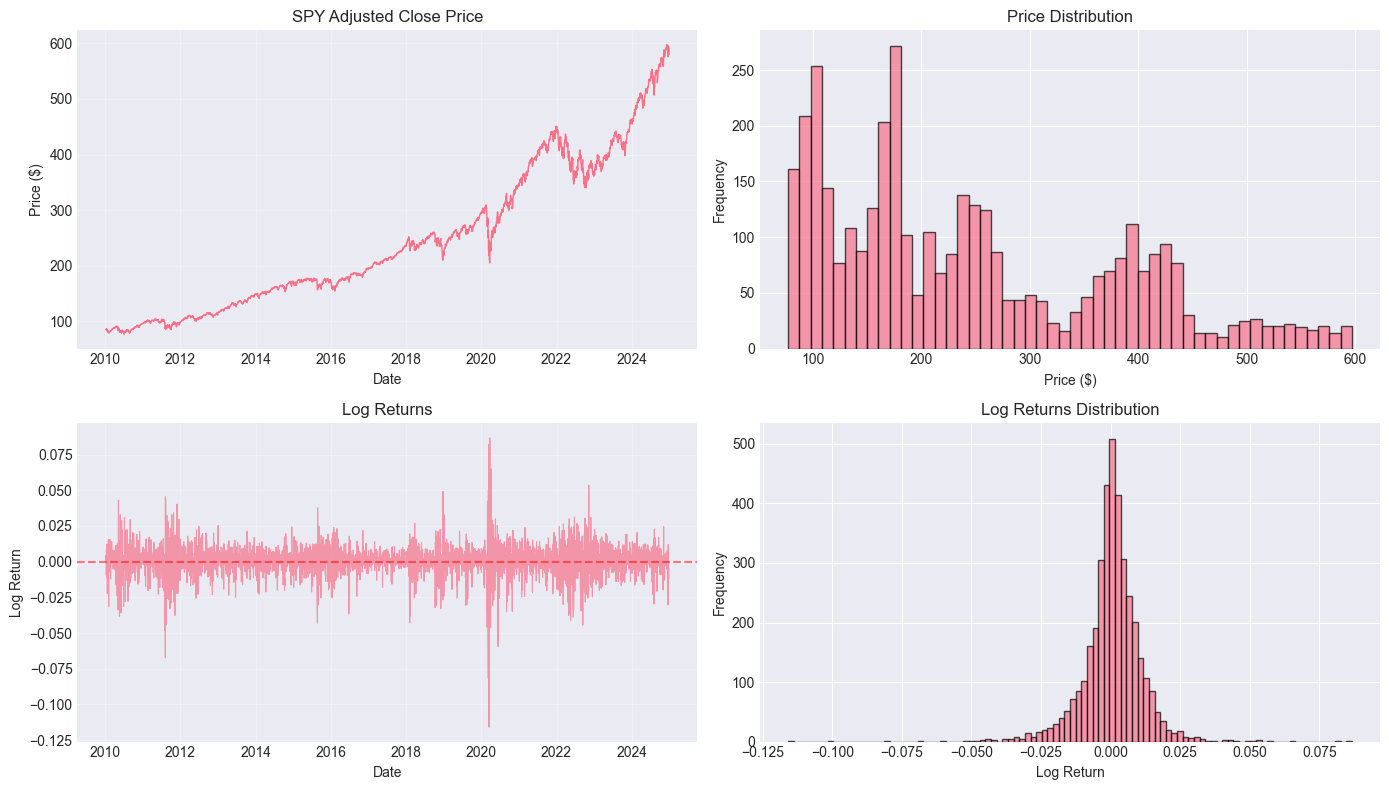

Returns statistics:
Mean: 0.000510
Std: 0.010774
Skewness: -0.7217
Kurtosis: 11.5420

Note: Kurtosis > 3 indicates fat tails (extreme events more likely than normal distribution)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Price time series
axes[0, 0].plot(df.index, df['price'], linewidth=1)
axes[0, 0].set_title('SPY Adjusted Close Price')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(alpha=0.3)

# Price histogram
axes[0, 1].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Price Distribution')
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_ylabel('Frequency')

# Returns time series
axes[1, 0].plot(df.index, df['log_return'], linewidth=0.8, alpha=0.7)
axes[1, 0].set_title('Log Returns')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Log Return')
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].grid(alpha=0.3)

# Returns histogram
axes[1, 1].hist(df['log_return'], bins=100, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Log Returns Distribution')
axes[1, 1].set_xlabel('Log Return')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/price_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Returns statistics:")
print(f"Mean: {df['log_return'].mean():.6f}")
print(f"Std: {df['log_return'].std():.6f}")
print(f"Skewness: {df['log_return'].skew():.4f}")
print(f"Kurtosis: {df['log_return'].kurtosis():.4f}")
print(f"\nNote: Kurtosis > 3 indicates fat tails (extreme events more likely than normal distribution)")

## 3. Non-Stationarity Analysis

We examine rolling statistics and perform the Augmented Dickey-Fuller test to assess stationarity.

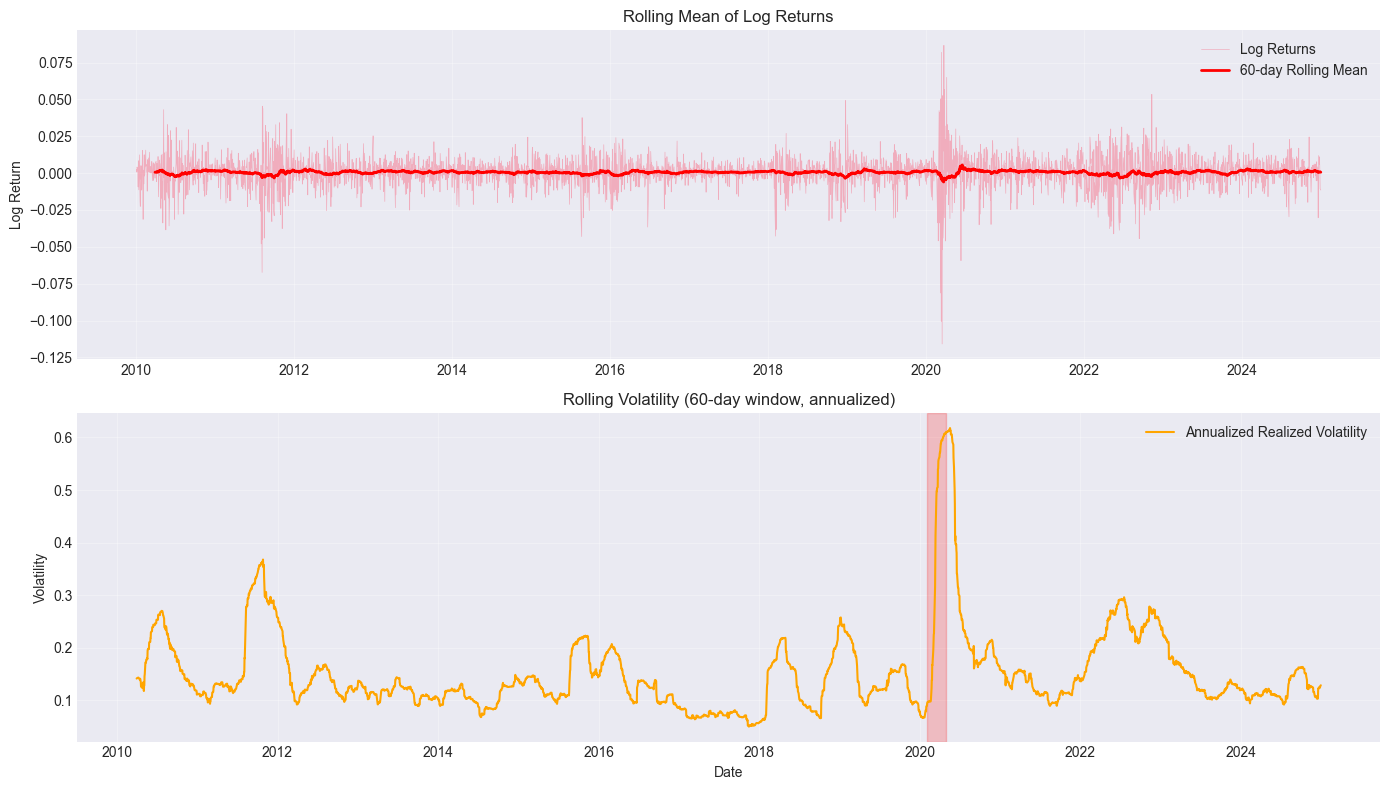

Observation: Volatility is clearly non-constant over time, with regime shifts during crisis periods.


In [6]:
# Compute rolling statistics
window = 60  # ~3 months
rolling_mean = df['log_return'].rolling(window).mean()
rolling_std = df['log_return'].rolling(window).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Rolling mean
axes[0].plot(df.index, df['log_return'], label='Log Returns', alpha=0.5, linewidth=0.5)
axes[0].plot(df.index, rolling_mean, label=f'{window}-day Rolling Mean', color='red', linewidth=2)
axes[0].set_title('Rolling Mean of Log Returns')
axes[0].set_ylabel('Log Return')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rolling std (realized volatility)
axes[1].plot(df.index, rolling_std * np.sqrt(252), label='Annualized Realized Volatility', color='orange', linewidth=1.5)
axes[1].set_title('Rolling Volatility (60-day window, annualized)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Highlight major volatility regimes
axes[1].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'), alpha=0.2, color='red', label='COVID Crash')

plt.tight_layout()
plt.savefig('../figures/rolling_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Volatility is clearly non-constant over time, with regime shifts during crisis periods.")

In [7]:
# Augmented Dickey-Fuller test
adf_result = adfuller(df['log_return'].dropna())
print("Augmented Dickey-Fuller Test for Log Returns:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Critical values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("\nConclusion: Returns are stationary (reject null hypothesis of unit root)")
else:
    print("\nConclusion: Cannot reject unit root hypothesis")

print("\nNote: While returns may be stationary in mean, volatility clustering violates i.i.d. assumptions.")

Augmented Dickey-Fuller Test for Log Returns:
ADF Statistic: -13.3328
p-value: 0.0000
Critical values: {'1%': np.float64(-3.432097339894967), '5%': np.float64(-2.862312078352202), '10%': np.float64(-2.567180988001804)}

Conclusion: Returns are stationary (reject null hypothesis of unit root)

Note: While returns may be stationary in mean, volatility clustering violates i.i.d. assumptions.


## 4. Autocorrelation Analysis

ACF and PACF plots help us understand temporal dependencies and justify the need for ML/DL models beyond simple ARIMA.

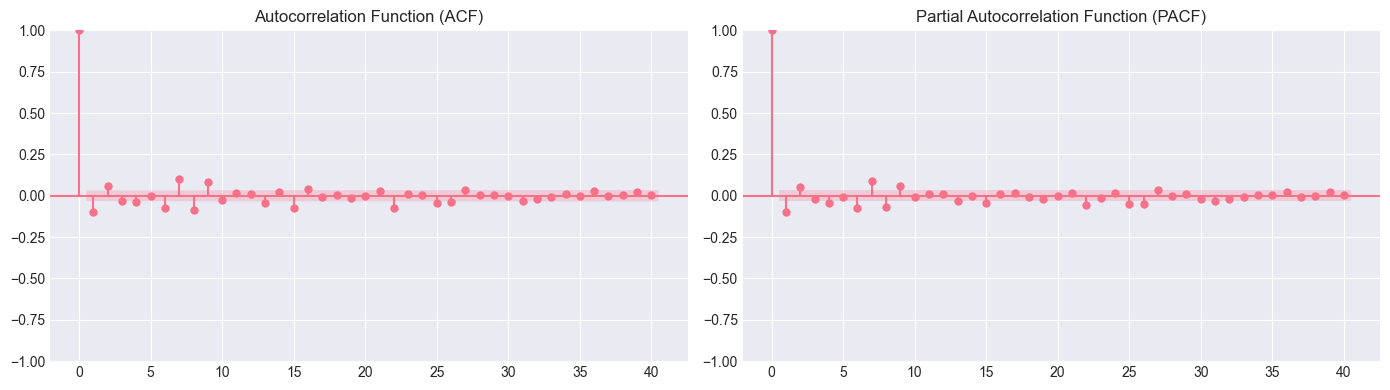

Observation: Weak autocorrelation in returns suggests limited linear predictability.
This motivates using non-linear ML/DL models that can capture complex patterns.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['log_return'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df['log_return'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.savefig('../figures/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Weak autocorrelation in returns suggests limited linear predictability.")
print("This motivates using non-linear ML/DL models that can capture complex patterns.")

## 5. VIX and Volatility Context

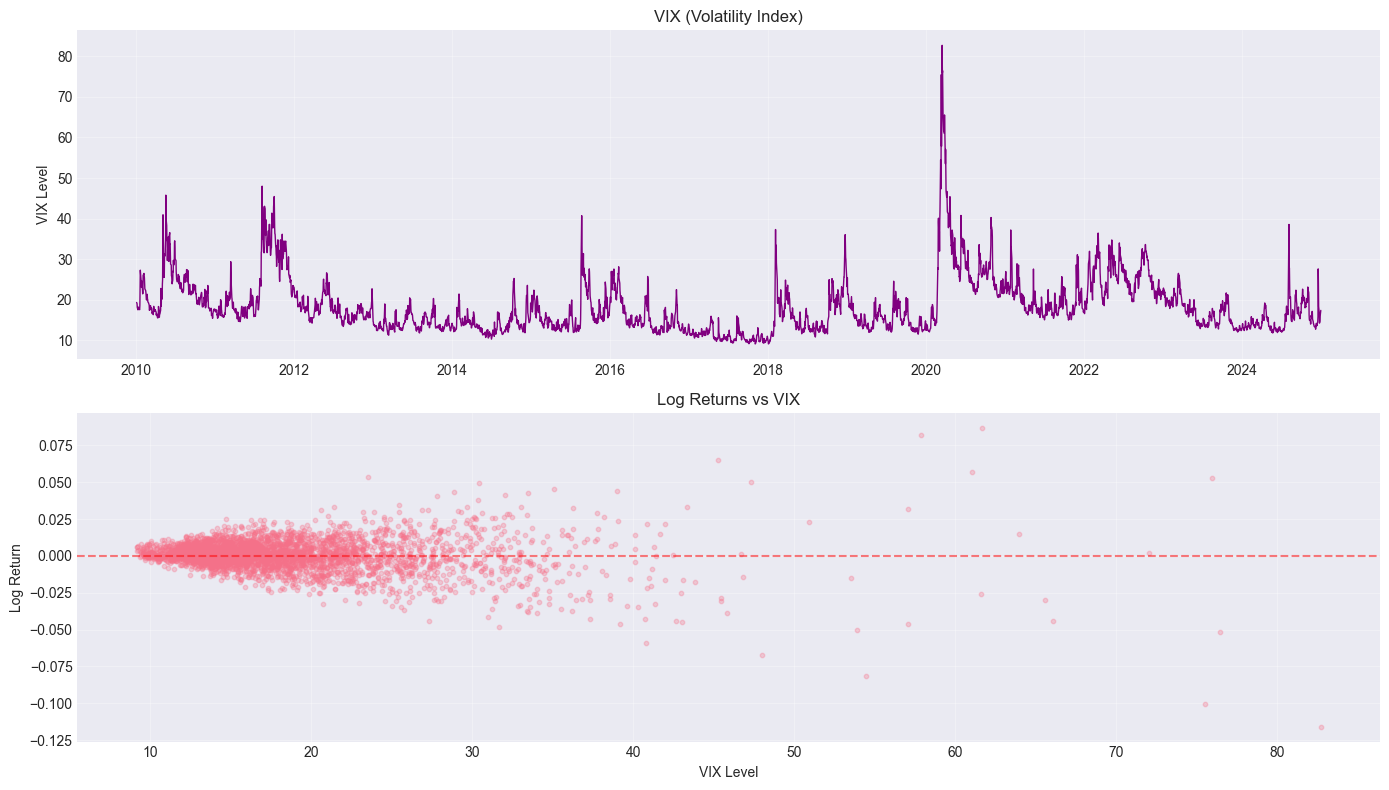

Correlation between VIX and returns: -0.1703
VIX provides valuable volatility context for forecasting.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# VIX time series
axes[0].plot(df.index, df['vix'], color='purple', linewidth=1)
axes[0].set_title('VIX (Volatility Index)')
axes[0].set_ylabel('VIX Level')
axes[0].grid(alpha=0.3)

# Scatter: returns vs VIX
axes[1].scatter(df['vix'], df['log_return'], alpha=0.3, s=10)
axes[1].set_title('Log Returns vs VIX')
axes[1].set_xlabel('VIX Level')
axes[1].set_ylabel('Log Return')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/vix_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation between VIX and returns: {df[['vix', 'log_return']].corr().iloc[0, 1]:.4f}")
print("VIX provides valuable volatility context for forecasting.")

## 6. Regime Analysis

We identify high and low volatility regimes to evaluate model robustness.

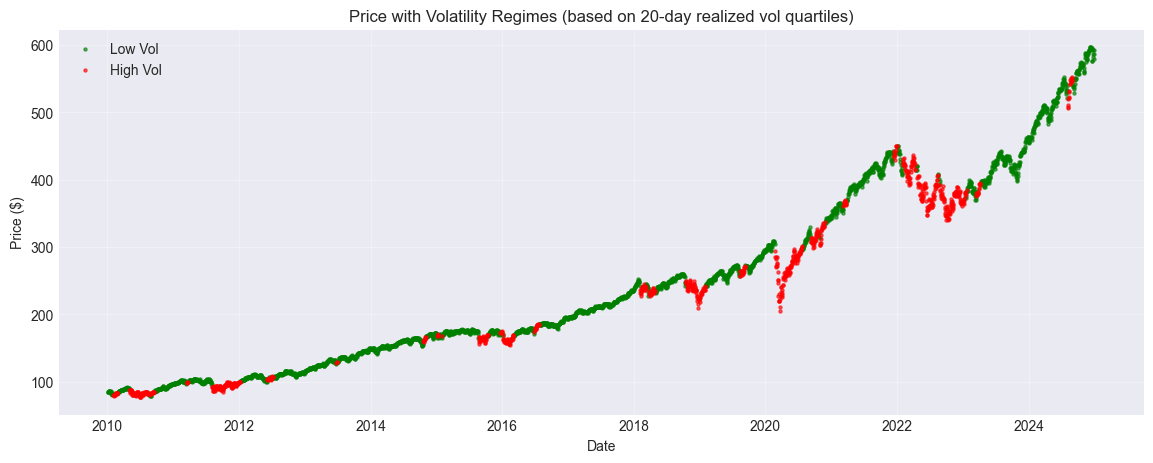

Regime distribution:
regime
low_vol     2834
high_vol     938
Name: count, dtype: int64

High volatility periods correspond to market stress (2020 COVID, 2022 rate hikes).


In [10]:
df = compute_regime_labels(df, window=20)

fig, ax = plt.subplots(figsize=(14, 5))

# Color-code by regime
for regime, color in [('low_vol', 'green'), ('high_vol', 'red')]:
    mask = df['regime'] == regime
    ax.scatter(df.index[mask], df.loc[mask, 'price'], 
              label=regime.replace('_', ' ').title(), 
              alpha=0.6, s=5, color=color)

ax.set_title('Price with Volatility Regimes (based on 20-day realized vol quartiles)')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig('../figures/regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Regime distribution:")
print(df['regime'].value_counts())
print("\nHigh volatility periods correspond to market stress (2020 COVID, 2022 rate hikes).")

## 7. Chronological Train/Validation/Test Split

**Critical for preventing data leakage:** We split data chronologically, never shuffling.

Train: 2010-01-05 to 2020-06-30 (2640 days)
Val:   2020-07-01 to 2022-09-28 (566 days)
Test:  2022-09-29 to 2024-12-30 (566 days)


Saved split visualization to ../figures/data_splits.png


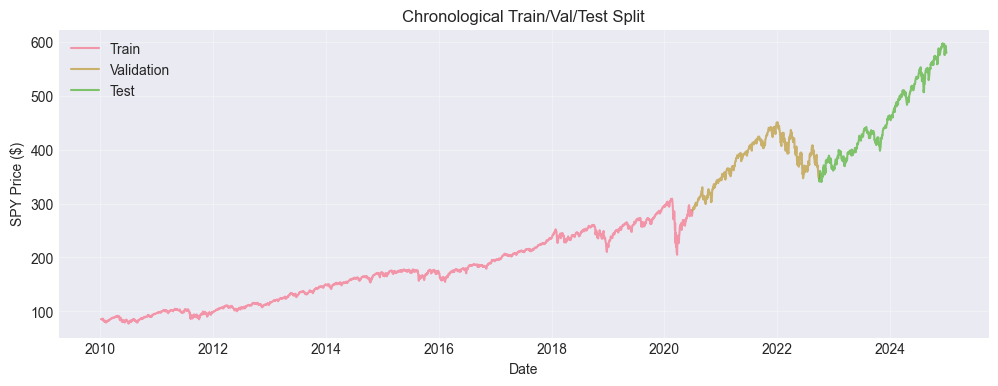

In [11]:
train_idx, val_idx, test_idx = chronological_split(df, train_frac=0.7, val_frac=0.15)

fig = plot_splits(df, train_idx, val_idx, test_idx, save_path='../figures/data_splits.png')
plt.show()

## 8. Key Findings Summary

1. **Data Quality**: 3,772 trading days from 2010-2024, no missing values after cleaning
2. **Non-Stationarity**: Clear volatility clustering and regime shifts (GFC aftermath, COVID, rate cycle)
3. **Fat Tails**: Returns exhibit excess kurtosis, indicating extreme events beyond normal distribution
4. **Weak Linear Autocorrelation**: ACF/PACF show limited linear structure, motivating non-linear models
5. **VIX Context**: Negative correlation with returns provides valuable volatility signal
6. **Regime Heterogeneity**: High-vol vs low-vol periods require robust forecasting approaches
7. **Leakage Prevention**: Strict chronological splits and causal feature engineering ensure valid evaluation

These findings justify our hybrid approach combining statistical baselines, ML with engineered features, and deep sequence models.